## Importación de librerias

In [1]:
import geopandas as gpd
import pandas as pd

import json
from shapely.geometry import shape

import matplotlib.pyplot as plt

import numpy as np

# Exploración de datos

## Archivo Límites de AGEB de zonas urbanas (Información del 2020)

Ninguna columna tiene celdas vacías

In [2]:
zonas_agebs = gpd.read_file("data/lmites-de-ageb-urbanas-en-la-ciudad-de-mxico.json")

zonas_agebs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2431 entries, 0 to 2430
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   CVEGEO    2431 non-null   object  
 1   CVE_ENT   2431 non-null   object  
 2   CVE_MUN   2431 non-null   object  
 3   CVE_LOC   2431 non-null   object  
 4   CVE_AGEB  2431 non-null   object  
 5   geometry  2431 non-null   geometry
dtypes: geometry(1), object(5)
memory usage: 114.1+ KB


In [3]:
zonas_agebs.head()

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry
0,0901000011716,09,010,0001,1716,"POLYGON ((-99.25882 19.32558, -99.25834 19.325..."
1,0901000012150,09,010,0001,2150,"POLYGON ((-99.1917 19.37893, -99.1917 19.37879..."
2,0901000011133,09,010,0001,1133,"POLYGON ((-99.1776 19.35182, -99.17766 19.3517..."
3,0901000011307,09,010,0001,1307,"POLYGON ((-99.20805 19.31277, -99.20768 19.312..."
4,0901000010281,09,010,0001,0281,"POLYGON ((-99.24228 19.38451, -99.24233 19.384..."


Gráfico del mapa de la CDMX con las zonas AGEB Urbanas

<Axes: >

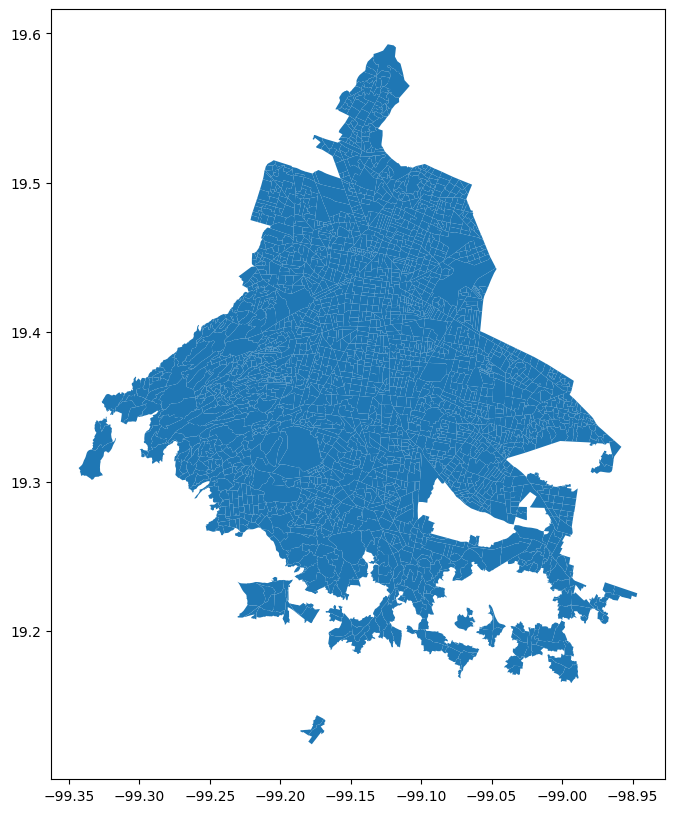

In [4]:
zonas_agebs.plot(figsize=(10, 10))

El dataset no cuenta con ninguna fila duplicada

In [5]:
zonas_agebs.duplicated().sum()

np.int64(0)

Se delimitaron la cantidad de datos a utilizar en el modelo a 4 alcaldías tienen un nivel de relevancia ya sea por las características del suelo, relevancia económica o por la cantidad de personas que la habitan.

In [6]:
# Iztapalapa -  Municipio: 007 (Oriente)
# Cuauhtémoc - Municipio: 015 (Centro)
# Benito Juárez - Municipio: 014 (Sur)
# Gustavo A. Madero - Municipio: 005 (Norte)
alcaldias_interes = ['007', '015', '014', '005']
zonas_filtradas = zonas_agebs[zonas_agebs['CVE_MUN'].isin(alcaldias_interes)]

Después de filtrar los datos, la cantidad de registros pasó de 2431 a 1018

In [7]:
zonas_filtradas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1018 entries, 406 to 2430
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   CVEGEO    1018 non-null   object  
 1   CVE_ENT   1018 non-null   object  
 2   CVE_MUN   1018 non-null   object  
 3   CVE_LOC   1018 non-null   object  
 4   CVE_AGEB  1018 non-null   object  
 5   geometry  1018 non-null   geometry
dtypes: geometry(1), object(5)
memory usage: 55.7+ KB


Debido a que es muy importante conocer el tipo de suelo que tiene cada zona, se debe conectar con otro dataset que contiene esa información.
Esto es debido a que las características del suelo contribuyen al nivel de riesgo que puede presentarse en una zona dependiendo del tipo de fenómeno

## Archivo de zonificacion geotecnica (Información del 2017)

Este dataset cuenta con solo 3 registros, ningúno con valores nulos.

In [8]:
gdf_suelo = gpd.read_file("data/zonificacion_geotecnica_2017.geojson")

gdf_suelo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    3 non-null      int32   
 1   fenomeno    3 non-null      object  
 2   taxonomia   3 non-null      object  
 3   r_p_v_e     3 non-null      object  
 4   intensidad  3 non-null      object  
 5   detalles    3 non-null      object  
 6   nombre      3 non-null      object  
 7   fuente      3 non-null      object  
 8   magni_uni   3 non-null      object  
 9   magni_num   3 non-null      int32   
 10  calle_y_nu  3 non-null      object  
 11  colonia     3 non-null      object  
 12  cve_mun     3 non-null      object  
 13  alcaldia    3 non-null      object  
 14  entidad     3 non-null      object  
 15  area_m2     3 non-null      float64 
 16  perime_m    3 non-null      float64 
 17  altitud     3 non-null      int32   
 18  geometry    3 non-null      geometry
dtypes: f

La columna más relevante es la "intensidad" ya que indica que características tiene la zona. En total hay 3 tipos de suelo:

* Zona I - Zona firme de lomas
    * Descripción: Formadas por rocas o suelos generalmente firmes que fueron depositados fuera del ambiente lacustre, pero en los que pueden existir, superficialmente o intercalados, depósitos arenosos en estado suelto o cohesivos relativamente blandos.

* Zona II - Zona de transición
    * Descripción: Los depósitos profundos se encuentran a 20 m de profundidad, o menos, y que está constituida predominantemente por estratos arenosos y limo arenosos intercalados con capas de arcilla lacustre.

* Zona III - Zona de lago
    * Descripción: Integrada por depósitos de arcilla altamente compresibles, separados por capas arenosas con contenido de limo o arcilla. Estas capas arenosas son en general medianamente compactas a muy compactas y de espesor variable de centímetros a varios metros

In [9]:
gdf_suelo.head()

,objectid,fenomeno,taxonomia,r_p_v_e,intensidad,detalles,nombre,fuente,magni_uni,magni_num,calle_y_nu,colonia,cve_mun,alcaldia,entidad,area_m2,perime_m,altitud,geometry
0,1,Geológico,Zonificación Geotécnica,Escenario,Zona III,Integrada por depósitos de arcilla altamente c...,Zona de lago,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,6.681231e+08,210769.53,0,"POLYGON ((503209.37 2167202.532, 497622.138 21..."
1,3,Geológico,Zonificación Geotécnica,Escenario,Zona II,Los depósitos profundos se encuentran a 20 m d...,Zona de transición,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,2.979016e+08,443179.48,0,"MULTIPOLYGON (((511931.137 2162742.282, 511843..."
2,2,Geológico,Zonificación Geotécnica,Escenario,Zona I,Formadas por rocas o suelos generalmente firme...,Zona firme de lomas,Normas Técnicas Complementarias para Diseño y ...,n/a,0,n/a,n/a,n/a,n/a,Ciudad de México,1.393378e+09,443131.00,0,"MULTIPOLYGON (((515760.302 2167166.974, 507823..."


Debido a que para el objetivo del proyecto no es relevante las direcciones o colonias en la CDMX, se eliminarán las columnas. Lo único importante es el tipo de zona y la cantidad de área cuadrada que tiene.

In [10]:
gdf_suelo = gdf_suelo.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'detalles', 'nombre', 'fuente', 'magni_uni', 'magni_num', 'calle_y_nu', 'colonia', 'cve_mun', 'alcaldia', 'entidad'])

In [11]:
gdf_suelo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   objectid    3 non-null      int32   
 1   intensidad  3 non-null      object  
 2   area_m2     3 non-null      float64 
 3   perime_m    3 non-null      float64 
 4   altitud     3 non-null      int32   
 5   geometry    3 non-null      geometry
dtypes: float64(2), geometry(1), int32(2), object(1)
memory usage: 252.0+ bytes


El dataset tampoco tiene ningún registro duplicado.

In [12]:
gdf_suelo.duplicated().sum()

np.int64(0)

Una vez filtrados los datos, el siguiente paso es enlazarlos con el dataset de las zonas AGEB urbanas. Debido a que el dataset de zonificación geotécnica no cuenta con una clave estandarizada (como la CVEGEO), la unión no puede hacerse de forma tabular simple; por ello, se recurre a un Join Espacial (Spatial Join).

Para que este proceso sea preciso, es fundamental que ambos conjuntos de datos compartan el mismo Sistema de Referencia de Coordenadas (CRS). Por estándar, los archivos GeoJSON utilizan coordenadas geográficas (WGS84), cuyas unidades son grados decimales (propios de sistemas GPS). Sin embargo, para realizar cálculos métricos exactos y asegurar que los polígonos encajen perfectamente, es necesario reproyectar los datos a un sistema de coordenadas proyectadas.

Esto permite pasar de una representación esférica de la Tierra a una representación en un "plano", donde las unidades de medida son metros.

In [13]:
gdf_suelo = gdf_suelo.to_crs(zonas_filtradas.crs)

gdf_suelo = gdf_suelo.rename(columns={'intensidad': 'tipo_suelo'})

gdf_suelo_clean = gdf_suelo[['tipo_suelo', 'area_m2', 'geometry']]

zonas_ageb_final= gpd.sjoin(zonas_filtradas, gdf_suelo_clean, how='left', predicate='intersects')

zonas_ageb_final = zonas_ageb_final.drop(columns=['index_right'])

In [14]:
zonas_ageb_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1286 entries, 406 to 2430
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      1286 non-null   object  
 1   CVE_ENT     1286 non-null   object  
 2   CVE_MUN     1286 non-null   object  
 3   CVE_LOC     1286 non-null   object  
 4   CVE_AGEB    1286 non-null   object  
 5   geometry    1286 non-null   geometry
 6   tipo_suelo  1286 non-null   object  
 7   area_m2     1286 non-null   float64 
dtypes: float64(1), geometry(1), object(6)
memory usage: 90.4+ KB


Anteriormente solo existian 1018 registros y después unir los datasets, la cantidad aumentó a 1286 registros. Esto significa que hay áreas AGEB que tienen más de un tipo de suelo, por lo que se dejará solo la zona más peligrosa asociada a esa área. El nivel de peligro es:

1. Nivel Bajo - Zona I
2. Nivel Medio - Zona II
3. Nivel Alto - Zona III

In [15]:
orden_suelo = {'Zona III': 3, 'Zona II': 2, 'Zona I': 1}
zonas_ageb_final['tipo_suelo'] = zonas_ageb_final['tipo_suelo'].map(orden_suelo)

zonas_ageb_final = zonas_ageb_final.sort_values('tipo_suelo', ascending=False)
zonas_ageb_final = zonas_ageb_final.drop_duplicates(subset='CVEGEO', keep='first')
zonas_ageb_final.rename(columns={'area_m2':'area_total'}, inplace=True)

In [16]:
zonas_ageb_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1018 entries, 2430 to 2410
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CVEGEO      1018 non-null   object  
 1   CVE_ENT     1018 non-null   object  
 2   CVE_MUN     1018 non-null   object  
 3   CVE_LOC     1018 non-null   object  
 4   CVE_AGEB    1018 non-null   object  
 5   geometry    1018 non-null   geometry
 6   tipo_suelo  1018 non-null   int64   
 7   area_total  1018 non-null   float64 
dtypes: float64(1), geometry(1), int64(1), object(5)
memory usage: 71.6+ KB


In [17]:
zonas_ageb_final.head()

,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVE_AGEB,geometry,tipo_suelo,area_total
2430,0900700011034,09,007,0001,1034,"POLYGON ((-99.0568 19.36313, -99.0576 19.35951...",3,6.681231e+08
2429,0900700013721,09,007,0001,3721,"POLYGON ((-99.06016 19.36342, -99.06042 19.362...",3,6.681231e+08
2417,0900700013647,09,007,0001,3647,"POLYGON ((-99.11409 19.37398, -99.11326 19.373...",3,6.681231e+08
2416,0900700015272,09,007,0001,5272,"POLYGON ((-99.12253 19.3757, -99.1217 19.37548...",3,6.681231e+08
2415,0900700010534,09,007,0001,0534,"POLYGON ((-99.11013 19.37348, -99.10959 19.373...",3,6.681231e+08


## Archivo Atlas de riesgo sismico (Información del 2019)

El dataset no cuenta con ninguna celda vacía.

In [18]:
sismos = pd.read_csv("data/atlas-de-riesgo-sismico.csv")
sismos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   object 
 2   geo_shape     4908 non-null   object 
 3   fenomeno      4908 non-null   object 
 4   taxonomia     4908 non-null   object 
 5   r_p_v_e       4908 non-null   object 
 6   intensidad    4908 non-null   object 
 7   descripcio    4908 non-null   object 
 8   fuente        4908 non-null   object 
 9   cvegeo        4908 non-null   object 
 10  alcaldia      4908 non-null   object 
 11  entidad       4908 non-null   object 
 12  area_m2       4908 non-null   float64
 13  perime_m      4908 non-null   float64
 14  int2          4908 non-null   int64  
dtypes: float64(3), int64(1), object(11)
memory usage: 575.3+ KB


Los datos más relevantes son:
* Intensidad: Indica el nivel de peligro que se puede presentar en la zona en caso de un sismo.

* CVEGEO: Es la clave estándar que permite unirlo al dataset de las zonas AGEB.

* area_m2: Representa la porción afectada de toda la zona AGEB.

* int2: Es la representación numérica de Intensidad.

In [19]:
sismos.head()

,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,int2
0,1411.0,"19.4774588726,-99.214475378","{""type"": ""Polygon"", ""coordinates"": [[[-99.2139...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900200010608,Azcapotzalco,Ciudad de México,177118.764865,2461.440128,3
1,1414.0,"19.4840766322,-99.0979827502","{""type"": ""Polygon"", ""coordinates"": [[[-99.0973...",Geológicos,Sísmico,Peligro,Muy Alto,AGEB localizado en las regiones donde antiguam...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900500011487,Gustavo A. Madero,Ciudad de México,137484.944478,1753.723791,5
2,1422.0,"19.5219195307,-99.1340171776","{""type"": ""Polygon"", ""coordinates"": [[[-99.1337...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900500012841,Gustavo A. Madero,Ciudad de México,84091.291297,1217.219854,3
3,1444.0,"19.3139677776,-99.1267177657","{""type"": ""Polygon"", ""coordinates"": [[[-99.1249...",Geológicos,Sísmico,Peligro,Muy Alto,AGEB localizado en las regiones donde antiguam...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900300010893,Coyoacán,Ciudad de México,271118.866925,2108.201526,5
4,1450.0,"19.3107975267,-99.1707434555","{""type"": ""Polygon"", ""coordinates"": [[[-99.1719...",Geológicos,Sísmico,Peligro,Medio,AGEB localizado en las partes más altas de la ...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0900300011567,Coyoacán,Ciudad de México,69468.042776,1072.146834,3


No tiene ningún registro duplicado.

In [20]:
sismos.duplicated().sum()

np.int64(0)

Para poder trabajar con solo las alcaldías seleccionadas, se deben filtrar los datos y para ello se debe trabajar con CVEGEO.

Esta clave de 13 dígitos se divide en 4 partes:

1. Estado (Clave de entidad federativa): Los primeros 2 dígitos.
2. Municipio o Alcaldía: Los siguientes 3 dígitos.
3. Localidad: Los siguientes 4 dígitos.
4. AGEB: Los últimos 4 dígitos.

Y la parte que permite filtrar los datos es la de municipio o alcaldía.

In [21]:
sismos['cve_mun'] = sismos['cvegeo'].str.slice(2, 5)

sismos_alcaldias = sismos[sismos['cve_mun'].isin(alcaldias_interes)].copy()

In [22]:
sismos_alcaldias.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 1 to 4884
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            2038 non-null   float64
 1   geo_point_2d  2038 non-null   object 
 2   geo_shape     2038 non-null   object 
 3   fenomeno      2038 non-null   object 
 4   taxonomia     2038 non-null   object 
 5   r_p_v_e       2038 non-null   object 
 6   intensidad    2038 non-null   object 
 7   descripcio    2038 non-null   object 
 8   fuente        2038 non-null   object 
 9   cvegeo        2038 non-null   object 
 10  alcaldia      2038 non-null   object 
 11  entidad       2038 non-null   object 
 12  area_m2       2038 non-null   float64
 13  perime_m      2038 non-null   float64
 14  int2          2038 non-null   int64  
 15  cve_mun       2038 non-null   object 
dtypes: float64(3), int64(1), object(12)
memory usage: 270.7+ KB


Hay varias columnas que no son necesarias para el objetivo del proyecto, por lo que se eliminaran para reducir la cantidad de memoria consumida.

In [23]:
sismos_alcaldias.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'fuente', 'alcaldia', 'entidad','descripcio', 'cve_mun'], inplace=True)

In [24]:
sismos_alcaldias.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 1 to 4884
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            2038 non-null   float64
 1   geo_point_2d  2038 non-null   object 
 2   geo_shape     2038 non-null   object 
 3   intensidad    2038 non-null   object 
 4   cvegeo        2038 non-null   object 
 5   area_m2       2038 non-null   float64
 6   perime_m      2038 non-null   float64
 7   int2          2038 non-null   int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 143.3+ KB


De esta forma se puede determinar que la columna int2 se refiere al nivel de intensidad pero de forma numérica.

La escala sería:
1. Muy Bajo
2. Bajo
3. Medio
4. Alto
5. Muy alto

In [25]:
sismos_final = sismos_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left'
)

sismos_final['pct_afectacion_sismo'] = (sismos_final['area_m2'] / sismos_final['area_total']) * 100

sismos_final['pct_afectacion_sismo'] = sismos_final['pct_afectacion_sismo'].clip(upper=100)


In [26]:
sismos_final = sismos_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left'
)

sismos_final['pct_afectacion_sismo'] = (sismos_final['area_m2'] / sismos_final['area_total']) * 100

sismos_final['pct_afectacion_sismo'] = sismos_final['pct_afectacion_sismo'].clip(upper=100)

sismos_final = sismos_final.sort_values(
    ['cvegeo', 'tipo_suelo'],
    ascending=[True, False]
)

sismos_ageb_unico = sismos_final.drop_duplicates(subset='cvegeo', keep='first').copy()

sismos_ageb_unico = sismos_ageb_unico.drop(columns=['CVEGEO', 'tipo_suelo', 'area_total'])

print(f"Registros finales: {len(sismos_ageb_unico)}")
print(sismos_ageb_unico[['cvegeo', 'pct_afectacion_sismo']].head())

Registros finales: 1019
             cvegeo  pct_afectacion_sismo
299   0900500010012              0.014513
1176  0900500010027              0.018731
1416  0900500010050              0.039766
159   0900500010084              0.025148
1219  0900500010099              0.014505


En este dataset de sismos se puede observar que al final quedan 1019 registros en lugar de 1018, esto puede ser por varios motivos:

* El dataset de zonas urbanas y el de los sismos tienen un año de diferencia, por lo que en el momento en que se realizó el estudio de los sismos había otra distribución de zonas o clasificación de urbano y rural.

* Puede ser un error humano en el que no se haya registrado esa zona en el dataset de zonas AGEB urbanas o que se hayan equivocado en el dataset de sismos.

In [27]:
sismos_ageb_unico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 299 to 45
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1019 non-null   float64
 1   geo_point_2d          1019 non-null   object 
 2   geo_shape             1019 non-null   object 
 3   intensidad            1019 non-null   object 
 4   cvegeo                1019 non-null   object 
 5   area_m2               1019 non-null   float64
 6   perime_m              1019 non-null   float64
 7   int2                  1019 non-null   int64  
 8   pct_afectacion_sismo  1018 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 79.6+ KB


Para resolver esta diferencia de tamaños, lo que se hará es descartar ese registro, puesto que elimintar un solo registro no representa una reducción de datos significativa para el modelo.

In [28]:
set_zonas = set(zonas_ageb_final['CVEGEO'].unique())
set_sismos = set(sismos_ageb_unico['cvegeo'].unique())

diferencia = set_sismos - set_zonas
print(diferencia)
if diferencia not in set_zonas:
  print('No se encuentra en el registro de las zonas AGEB')

{'0900500012502'}
No se encuentra en el registro de las zonas AGEB


In [29]:
sismos_ageb_unico = sismos_ageb_unico[sismos_ageb_unico['cvegeo'] != '0900500012502']

print(f"Total de registros finales confirmados: {len(sismos_ageb_unico)}")

Total de registros finales confirmados: 1018


In [30]:
sismos_ageb_unico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1018 entries, 299 to 45
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1018 non-null   float64
 1   geo_point_2d          1018 non-null   object 
 2   geo_shape             1018 non-null   object 
 3   intensidad            1018 non-null   object 
 4   cvegeo                1018 non-null   object 
 5   area_m2               1018 non-null   float64
 6   perime_m              1018 non-null   float64
 7   int2                  1018 non-null   int64  
 8   pct_afectacion_sismo  1018 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 79.5+ KB


Para poder representar el nivel de riesgo en las zonas AGEB dentro de un mapa de la CDMX, es necesario que la columna geometry sea un objeto geométrico para manipularlo con un sistema de coordenadas.

In [31]:
def parse_geometry(x):
    try:
        if isinstance(x, str):
            return shape(json.loads(x))
        elif isinstance(x, dict):
            return shape(x)
        return None
    except:
        return None

Representación de toda la CDMX

<Axes: >

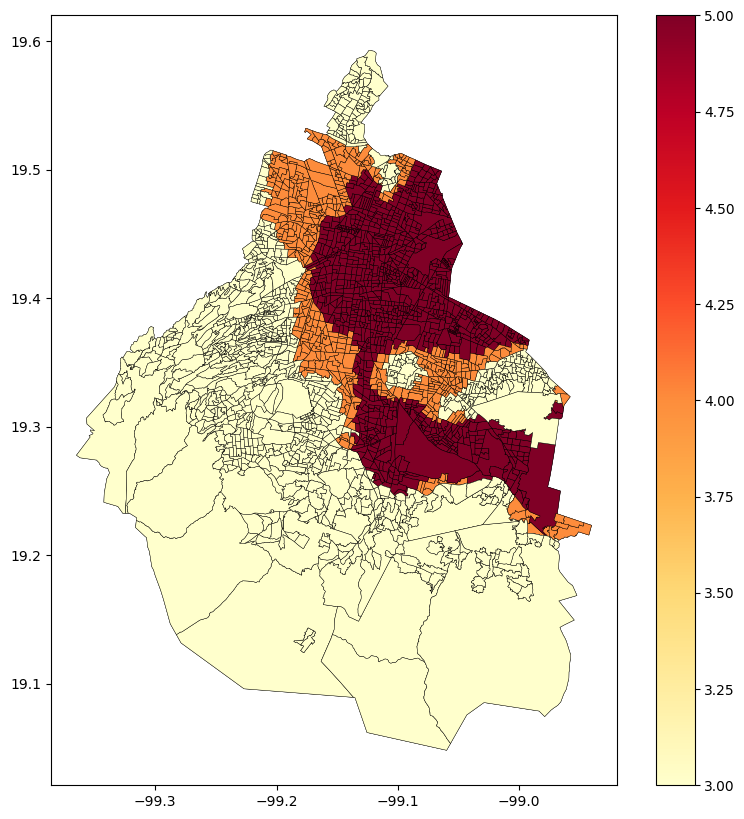

In [32]:
sismos['geometry'] = sismos['geo_shape'].apply(parse_geometry)

sismos_gdf = gpd.GeoDataFrame(sismos, geometry='geometry')

sismos_gdf.crs = "EPSG:4326"

sismos_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

Representación de las 4 alcaldías

<Axes: >

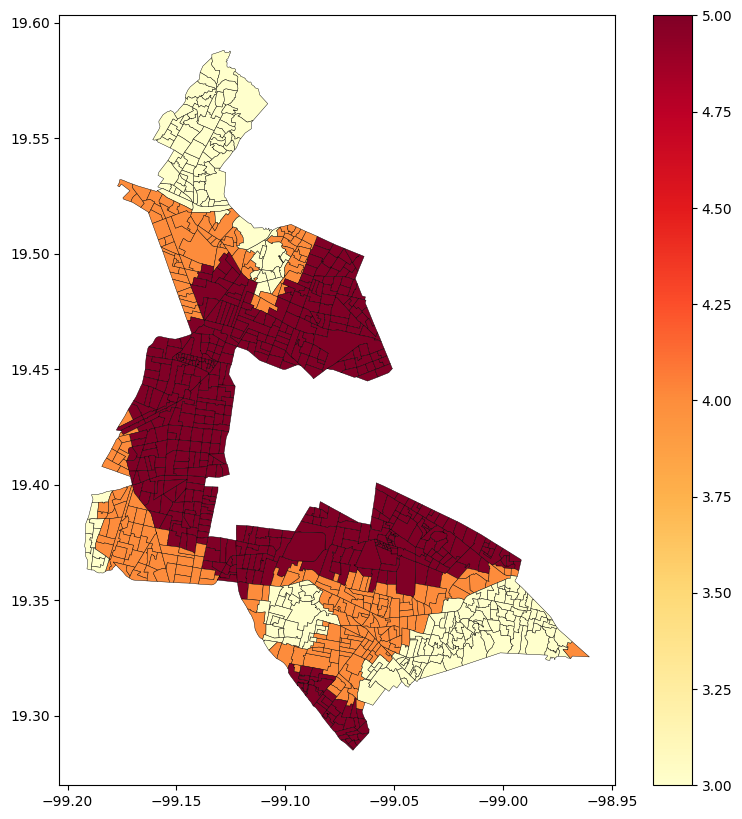

In [33]:
sismos_ageb_unico['geometry'] = sismos_ageb_unico['geo_shape'].apply(parse_geometry)

sismos_gdf = gpd.GeoDataFrame(sismos_ageb_unico, geometry='geometry')

sismos_gdf.crs = "EPSG:4326"

sismos_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

## Archivo Inundaciones (Información del 2019)

No tiene ningúna celda vacía.

In [34]:
inundaciones = pd.read_csv("data/atlas-de-riesgo-inundaciones.csv")

inundaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   object 
 2   geo_shape     4908 non-null   object 
 3   fenomeno      4908 non-null   object 
 4   taxonomia     4908 non-null   object 
 5   r_p_v_e       4908 non-null   object 
 6   intensidad    4908 non-null   object 
 7   descripcio    4908 non-null   object 
 8   fuente        4908 non-null   object 
 9   cvegeo        4908 non-null   object 
 10  alcaldia      4908 non-null   object 
 11  entidad       4908 non-null   object 
 12  area_m2       4908 non-null   float64
 13  perime_m      4908 non-null   float64
 14  period_ret    4908 non-null   object 
 15  intens_uni    4908 non-null   object 
 16  intens_num    4908 non-null   object 
 17  int2          4908 non-null   int64  
dtypes: float64(3), int64(1), obj

Los datos más relevante son:

* Intensidad: Representa el nivel de peligro (de forma categórica) que tiene una zona al presentarse una inundación.

* area_m2: Indica el área afectada

* intens_num: Indica el porcentaje del área que se puede inundar.

* int2: Indica la intensidad pero de forma numérica.

In [35]:
inundaciones.head()

,id,geo_point_2d,geo_shape,fenomeno,taxonomia,r_p_v_e,intensidad,descripcio,fuente,cvegeo,alcaldia,entidad,area_m2,perime_m,period_ret,intens_uni,intens_num,int2
0,35.0,"19.2422518066,-99.0731823535","{""type"": ""Polygon"", ""coordinates"": [[[-99.0760...",Hidrometeorológicos,Inundaciones,Peligro,Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300011154,Xochimilco,Ciudad de México,973904.029201,6805.448256,5 años,% de area inundable,26 a 49,2
1,56.0,"19.2236128042,-99.1083418839","{""type"": ""Polygon"", ""coordinates"": [[[-99.1064...",Hidrometeorológicos,Inundaciones,Peligro,Muy Bajo,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010601,Xochimilco,Ciudad de México,795548.364401,4693.752691,5 años,% de area inundable,0 a 25,1
2,32.0,"19.3809650541,-99.1373113251","{""type"": ""Polygon"", ""coordinates"": [[[-99.1366...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901400010524,Benito Juárez,Ciudad de México,168263.324089,1712.409605,5 años,% de area inundable,100,5
3,45.0,"19.2603567,-99.0628861422","{""type"": ""Polygon"", ""coordinates"": [[[-99.0614...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901300010724,Xochimilco,Ciudad de México,267499.368896,2488.603256,5 años,% de area inundable,100,5
4,31.0,"19.3905750675,-99.144452701","{""type"": ""Polygon"", ""coordinates"": [[[-99.1445...",Hidrometeorológicos,Inundaciones,Peligro,Muy Alto,Análisis del índice de Inundabilidad de la CON...,"Dirección de Análisis de Riesgo de la SPCGIR, ...",0901400010280,Benito Juárez,Ciudad de México,202062.408324,2113.713857,5 años,% de area inundable,100,5


In [36]:
inundaciones.drop(columns=['fenomeno', 'taxonomia', 'r_p_v_e', 'fuente', 'alcaldia', 'entidad','descripcio', 'period_ret', 'intens_uni'], inplace=True)

In [37]:
inundaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4908 entries, 0 to 4907
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            4908 non-null   float64
 1   geo_point_2d  4908 non-null   object 
 2   geo_shape     4908 non-null   object 
 3   intensidad    4908 non-null   object 
 4   cvegeo        4908 non-null   object 
 5   area_m2       4908 non-null   float64
 6   perime_m      4908 non-null   float64
 7   intens_num    4908 non-null   object 
 8   int2          4908 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 345.2+ KB


No tiene ningún registro duplicado.

In [38]:
inundaciones.duplicated().sum()

np.int64(0)

En este dataset también se tienen que filtrar los datos de las alcaldías seleccionadas.

In [39]:
inundaciones['cve_mun'] = inundaciones['cvegeo'].str.slice(2, 5)

inundaciones_alcaldias = inundaciones[inundaciones['cve_mun'].isin(alcaldias_interes)].copy()

inundaciones_alcaldias.drop(columns=['cve_mun'], inplace=True)

In [40]:
inundaciones_alcaldias.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 2 to 4907
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            2038 non-null   float64
 1   geo_point_2d  2038 non-null   object 
 2   geo_shape     2038 non-null   object 
 3   intensidad    2038 non-null   object 
 4   cvegeo        2038 non-null   object 
 5   area_m2       2038 non-null   float64
 6   perime_m      2038 non-null   float64
 7   intens_num    2038 non-null   object 
 8   int2          2038 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 159.2+ KB


La columna intens_num tiene información relevante porque indica un rango de porcentajes en los cuales se puede llegar a inundar el área, pero para poder trabajarla en el modelo, lo que se realizará es convertir esa cadena a números y obtener el promedio del porcentaje de inundación que puede llegar a tener esa área.

In [41]:
inundaciones_alcaldias['intens_num'].unique()

array(['100', '73 a 99', '26 a 49', '0 a 25', '50 a 72'], dtype=object)

In [42]:
def limpiar_intensidad_rango(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    if ' a ' in valor:
        try:
            partes = valor.split(' a ')
            limite_inferior = float(partes[0])
            limite_superior = float(partes[1])
            return (limite_inferior + limite_superior) / 2
        except ValueError:
            return np.nan

    try:
        return float(valor)
    except ValueError:
        return np.nan

In [43]:
inundaciones_final = inundaciones_alcaldias.merge(
    zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'area_total']],
    left_on='cvegeo',
    right_on='CVEGEO',
    how='left'
)

inundaciones_final['intens_num_limpia'] = inundaciones_final['intens_num'].apply(limpiar_intensidad_rango)

inundaciones_final['pct_afectacion_inundacion'] = (inundaciones_final['area_m2'] / inundaciones_final['area_total']) * 100
inundaciones_final['pct_afectacion_inundacion'] = inundaciones_final['pct_afectacion_inundacion'].clip(upper=100)

inundaciones_final = inundaciones_final.sort_values(
    ['cvegeo', 'tipo_suelo', 'intens_num_limpia'],
    ascending=[True, False, False]
)

inundaciones_ageb_unico = inundaciones_final[inundaciones_final['cvegeo'].isin(set_zonas)]

inundaciones_ageb_unico = inundaciones_final.drop_duplicates(subset='cvegeo', keep='first').copy()

inundaciones_ageb_unico = inundaciones_ageb_unico.drop(columns=['CVEGEO', 'tipo_suelo', 'area_total'])

print(f"Registros finales: {len(inundaciones_ageb_unico)}")
print(inundaciones_ageb_unico[['cvegeo', 'pct_afectacion_inundacion']].head())

Registros finales: 1019
             cvegeo  pct_afectacion_inundacion
1091  0900500010012                   0.014513
435   0900500010027                   0.018731
46    0900500010050                   0.039766
1390  0900500010084                   0.025148
116   0900500010099                   0.014505


In [44]:
inundaciones_ageb_unico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 1091 to 484
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1019 non-null   float64
 1   geo_point_2d               1019 non-null   object 
 2   geo_shape                  1019 non-null   object 
 3   intensidad                 1019 non-null   object 
 4   cvegeo                     1019 non-null   object 
 5   area_m2                    1019 non-null   float64
 6   perime_m                   1019 non-null   float64
 7   intens_num                 1019 non-null   object 
 8   int2                       1019 non-null   int64  
 9   intens_num_limpia          1019 non-null   float64
 10  pct_afectacion_inundacion  1018 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 95.5+ KB


In [45]:
inundaciones_ageb_unico = inundaciones_ageb_unico[inundaciones_ageb_unico['cvegeo'].isin(set_zonas)].copy()

print(f"Total de registros finales: {len(inundaciones_ageb_unico)}")

Total de registros finales: 1018


In [46]:
inundaciones_ageb_unico.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1018 entries, 1091 to 484
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1018 non-null   float64
 1   geo_point_2d               1018 non-null   object 
 2   geo_shape                  1018 non-null   object 
 3   intensidad                 1018 non-null   object 
 4   cvegeo                     1018 non-null   object 
 5   area_m2                    1018 non-null   float64
 6   perime_m                   1018 non-null   float64
 7   intens_num                 1018 non-null   object 
 8   int2                       1018 non-null   int64  
 9   intens_num_limpia          1018 non-null   float64
 10  pct_afectacion_inundacion  1018 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 95.4+ KB


In [47]:
inundaciones_ageb_unico.head()

,id,geo_point_2d,geo_shape,intensidad,cvegeo,area_m2,perime_m,intens_num,int2,intens_num_limpia,pct_afectacion_inundacion
1091,1341.0,"19.5688029523,-99.1349354086","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Muy Bajo,0900500010012,202225.061171,2679.182547,0 a 25,1,12.5,0.014513
435,2156.0,"19.5657452918,-99.1373797858","{""type"": ""Polygon"", ""coordinates"": [[[-99.1344...",Muy Bajo,0900500010027,260995.968419,2756.847523,0 a 25,1,12.5,0.018731
46,2121.0,"19.5572202306,-99.1351617598","{""type"": ""Polygon"", ""coordinates"": [[[-99.1359...",Bajo,0900500010050,554095.206719,3842.846650,26 a 49,2,37.5,0.039766
1390,1469.0,"19.5561413312,-99.1418537903","{""type"": ""MultiPolygon"", ""coordinates"": [[[[-9...",Muy Bajo,0900500010084,350410.708602,3313.433734,0 a 25,1,12.5,0.025148
116,1265.0,"19.5535450617,-99.1513117562","{""type"": ""Polygon"", ""coordinates"": [[[-99.1532...",Muy Bajo,0900500010099,202102.865021,2026.549212,0 a 25,1,12.5,0.014505


Representación del nivel de riesgo de inundación en la CDMX.

<Axes: >

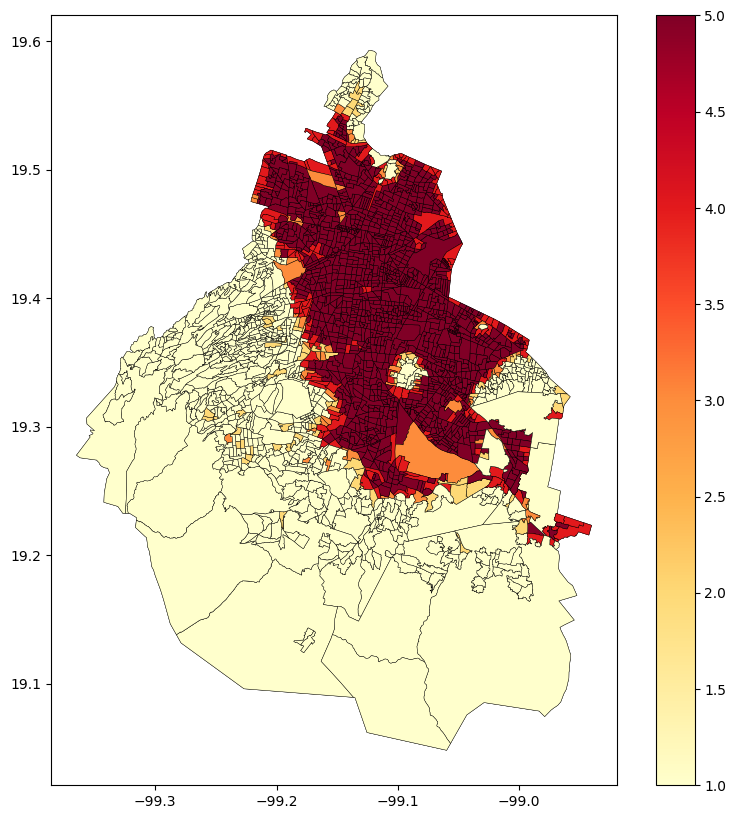

In [48]:
inundaciones['geometry'] = inundaciones['geo_shape'].apply(parse_geometry)

inundaciones_gdf = gpd.GeoDataFrame(inundaciones, geometry='geometry')

inundaciones_gdf.crs = "EPSG:4326"

inundaciones_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

Representación de riesgo en las alcaldías seleccionadas.

<Axes: >

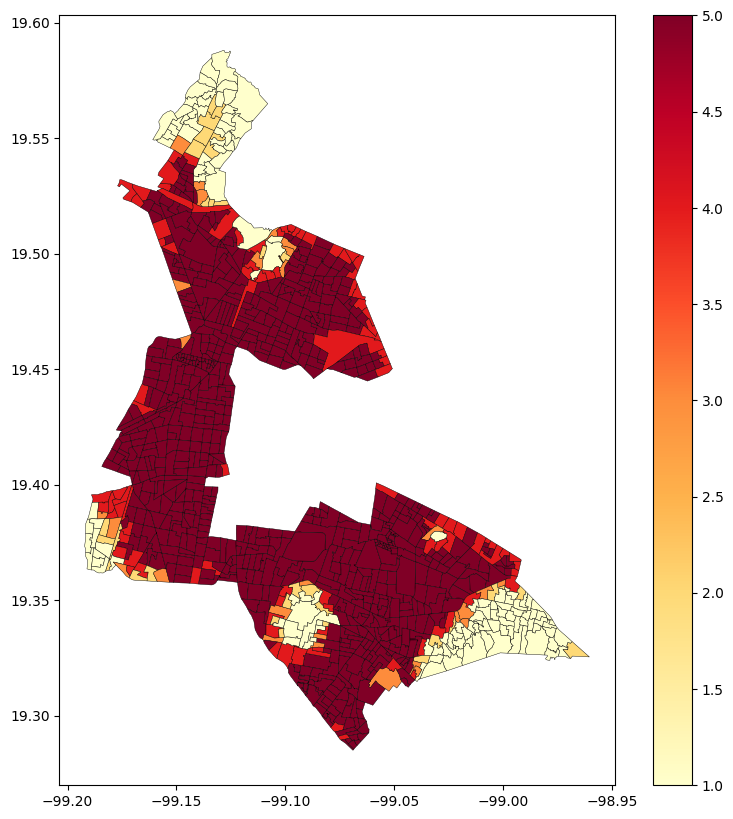

In [49]:
inundaciones_ageb_unico['geometry'] = inundaciones_ageb_unico['geo_shape'].apply(parse_geometry)

inundaciones_gdf = gpd.GeoDataFrame(inundaciones_ageb_unico, geometry='geometry')

inundaciones_gdf.crs = "EPSG:4326"

inundaciones_gdf.plot(column='int2', cmap='YlOrRd', figsize=(10, 10), edgecolor='black', linewidth=0.3, legend=True)

## Archivo Registro Único de Situaciones de Emergencia

El objetivo de este dataset es para evaluar al modelo.
En caso de que hubiera una situación de emergencia en una zona AGEB, se debería de concluir que con los niveles de riesgo indicado, concuerdan con que efectivamente hubo un incidente y que con los detalles de ese incidente se puede determinar que tan grave fue.

In [50]:
ruse = pd.read_csv("data/registro-unico-de-situaciones-de-emergencia.csv")

ruse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31589 entries, 0 to 31588
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            31589 non-null  int64  
 1   geo_point_2d  31589 non-null  object 
 2   geo_shape     31589 non-null  object 
 3   folio         31589 non-null  int64  
 4   fecha         31589 non-null  object 
 5   hora          31289 non-null  object 
 6   fenomeno      31589 non-null  object 
 7   taxonomia     31588 non-null  object 
 8   grupo         31589 non-null  object 
 9   incidente     31589 non-null  object 
 10  causas        31568 non-null  object 
 11  calle_y_nu    31589 non-null  object 
 12  colonia       31586 non-null  object 
 13  alcaldia      31589 non-null  object 
 14  atendio       31586 non-null  object 
 15  atendio_dg    31571 non-null  object 
 16  fuente        31586 non-null  object 
 17  atencion      31589 non-null  object 
 18  seguimie      31554 non-nu

In [51]:
ruse.head()

,id,geo_point_2d,geo_shape,folio,fecha,hora,fenomeno,taxonomia,grupo,incidente,...,alcaldia,atendio,atendio_dg,fuente,atencion,seguimie,lesionados,fallecidos,latitud,longitud
0,10001,"19.31089531,-99.05992219","{""type"": ""Point"", ""coordinates"": [-99.05992219...",391,25/01/2019,21:30:00,QUIMICO-TECNOLOGICO,INCENDIO URBANO,NO APLICA,INCENDIO DE PASTO EN BALDIO O CAMELLON,...,IZTAPALAPA,"HCB, SSC","REGIONAL ORIENTE, S.-13 Y S.-30 (TIEMPO DE RES...",SSC,"EN EL PANTEON “SAN LORENZO TEZONCO”, SE SUSCIT...",NO APLICA,0,0,19.310895,-99.059922
1,10002,"19.30106176,-99.17409218","{""type"": ""Point"", ""coordinates"": [-99.17409217...",392,25/01/2019,23:35:00,QUIMICO-TECNOLOGICO,DERRAME O FUGA DE SUSTANCIA PELIGROSA,NO APLICA,FUGA DE GAS NATURAL EN TOMAS DOMICILIARIAS,...,TLALPAN,"HCB, SAC, GAS NATUTGY",NO RELEVANTE,FRECUENCIA DE RADIO,SE SUSCITO FUGA DE GAS NATURAL EN TUBERIA DE A...,NO APLICA,0,0,19.301062,-99.174092
2,10008,"19.33917957,-99.31114328","{""type"": ""Point"", ""coordinates"": [-99.31114327...",398,26/01/2019,12:38:00,SOCIORGANIZATIVO,ACCIDENTES TERRESTRES,NO APLICA,ACCIDENTES EN TRANSPORTE DE CARGA,...,CUAJIMALPA DE MORELOS,POLICIA FEDERAL,NO RELEVANTE,FRECUENCIA DE RADIO,SE TUVO CONOCIMIENTO DE LA VOLCADURA DE UN CAM...,NO APLICA,1,0,19.339180,-99.311143
3,10010,"19.33213585,-99.0767522","{""type"": ""Point"", ""coordinates"": [-99.0767522,...",400,26/01/2019,14:14:00,QUIMICO-TECNOLOGICO,INCENDIO URBANO,NO APLICA,INCENDIO EN TRANSPORTE DE CARGA,...,IZTAPALAPA,"UPC, SSC",S.-10 Y S.-16 (TIEMPO DE RESPUESTA 13 MIN.),SSC,"SOBRE LA VIA PUBLICA, A CONSECUENCIA DE CORTO ...",NO APLICA,0,0,19.332136,-99.076752
4,10014,"19.38728094,-99.13886126","{""type"": ""Point"", ""coordinates"": [-99.13886126...",404,27/01/2019,01:38:00,SOCIORGANIZATIVO,ACCIDENTES TERRESTRES,NO APLICA,ACCIDENTES EN VEHICULOS PARTICULARES,...,BENITO JUAREZ,SSC,NO RELEVANTE,SSC,"UN VEHICULO PARTICULAR, IMPACTO UNA DOVELA DE ...",NO APLICA,1,0,19.387281,-99.138861


In [52]:
ruse.duplicated().sum()

np.int64(0)

## Generación del dataset final

Para la creación del dataset final con el que se trabajará, se hará uso de 4 datasets:

* Zonas AGEB Urbanas: Clasificación de las zonas AGEB urbanas en la CDMX.

* Zonificación geotécnica: Información sobre el tipo de zona.

* Atlas de riesgo - Sismos: Información sobre que tanto peligro/riesgo existe en una zona dependiendo de las características de la zona cuando ocurre un sismo.

* Atlas de riesgo - Inundaciones: Información sobre que tanto peligro/riesgo existe en una zona dependiendo de las características de la zona cuando ocurre una inundación.

Las columnas relevantes del atlas de riesgo de sismos son el nivel de peligro numérico y el porcentaje del área afectada.

Las columnas relevantes del atlas de riesgo de inunndación son el nivel de peligro numérico y el porcentaje del área que se puede inundar.


In [53]:
sismos_para_merge = sismos_ageb_unico[['cvegeo', 'int2', 'pct_afectacion_sismo']].rename(
    columns={'int2': 'riesgo_sismo'}
)

zonas_ageb_final = zonas_ageb_final.merge(
    sismos_para_merge,
    left_on='CVEGEO',
    right_on='cvegeo',
    how='left'
)

zonas_ageb_final = zonas_ageb_final.drop(columns=['cvegeo'])
zonas_ageb_final[['riesgo_sismo', 'pct_afectacion_sismo']] = zonas_ageb_final[['riesgo_sismo', 'pct_afectacion_sismo']].fillna(0)

print(f"Columnas actuales: {zonas_ageb_final.columns.tolist()}")
print(f"Total de registros: {len(zonas_ageb_final)}")
print(zonas_ageb_final[['CVEGEO', 'tipo_suelo', 'riesgo_sismo', 'pct_afectacion_sismo']].head())

Columnas actuales: ['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry', 'tipo_suelo', 'area_total', 'riesgo_sismo', 'pct_afectacion_sismo']
Total de registros: 1018
          CVEGEO  tipo_suelo  riesgo_sismo  pct_afectacion_sismo
0  0900700011034           3             5              0.051608
1  0900700013721           3             5              0.033589
2  0900700013647           3             5              0.017394
3  0900700015272           3             5              0.033003
4  0900700010534           3             5              0.051723


In [54]:
inundaciones_para_merge = inundaciones_ageb_unico[['cvegeo', 'int2', 'intens_num_limpia', 'pct_afectacion_inundacion']].rename(
    columns={
        'int2': 'riesgo_inundacion',
        'intens_num_limpia': 'severidad_inundacion'
    }
)

zonas_ageb_final = zonas_ageb_final.merge(
    inundaciones_para_merge,
    left_on='CVEGEO',
    right_on='cvegeo',
    how='left'
)

zonas_ageb_final = zonas_ageb_final.drop(columns=['cvegeo'])
cols_llenar = ['riesgo_inundacion', 'severidad_inundacion', 'pct_afectacion_inundacion']
zonas_ageb_final[cols_llenar] = zonas_ageb_final[cols_llenar].fillna(0)



Como el modelo será supervisado, se debe de generar una etiqueta final que se va a definir de la siguiente manera:

1. Las columnas de riesgo_inundacion y riesgo_sismo pueden llegar a tener valores entre 1 y 5, por lo que al sumarse, puede haber un valor máximo de 10.

2. A partir de esto se puede generar un "semáforo de riesgo" que tiene la siguiente escala:
    * Nivel de riesgo Bajo: Para valores entre 1 a 2.
    * Nivel de riesgo Bajo-Medio: Para valores entre 3 a 4.
    * Nivel de riesgo Medio: Para valores entre 5 a 6.
    * Nivel de riesgo Medio/Alto: Para valores entre 7 y 8.
    * Nivel de riesgo Alto: Para valores entre 9 y 10.

Y para que el modelo pueda trabajar con esta información de mejor manera, se manejará de forma numérica donde:
* Bajo se representa con el número 1.
* Bajo se representa con el número 2.
* Bajo se representa con el número 3.
* Medio se representa con el número 4.
* Alto se representa con el número 5.

In [55]:
zonas_ageb_final['suma_riesgos'] = zonas_ageb_final['riesgo_sismo'] + zonas_ageb_final['riesgo_inundacion']

condiciones = [
    (zonas_ageb_final['suma_riesgos'] >= 1) & (zonas_ageb_final['suma_riesgos'] <= 2),
    (zonas_ageb_final['suma_riesgos'] >= 3) & (zonas_ageb_final['suma_riesgos'] <= 4),
    (zonas_ageb_final['suma_riesgos'] >= 5) & (zonas_ageb_final['suma_riesgos'] <= 6),
    (zonas_ageb_final['suma_riesgos'] >= 7) & (zonas_ageb_final['suma_riesgos'] <= 8),
    (zonas_ageb_final['suma_riesgos'] >= 9) & (zonas_ageb_final['suma_riesgos'] <= 10)
]

valores_riesgo = [1, 2, 3, 4, 5]

zonas_ageb_final['riesgo_general'] = np.select(condiciones, valores_riesgo, default=0)

zonas_ageb_final = zonas_ageb_final.drop(
    columns=['pct_afectacion_sismo', 'severidad_inundacion'],
    errors='ignore'
)

print(f"Columnas actuales: {zonas_ageb_final.columns.tolist()}")

print(zonas_ageb_final[['CVEGEO', 'riesgo_sismo', 'riesgo_inundacion', 'suma_riesgos', 'riesgo_general']].head())

Columnas actuales: ['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry', 'tipo_suelo', 'area_total', 'riesgo_sismo', 'riesgo_inundacion', 'pct_afectacion_inundacion', 'suma_riesgos', 'riesgo_general']
          CVEGEO  riesgo_sismo  riesgo_inundacion  suma_riesgos  \
0  0900700011034             5                  5            10   
1  0900700013721             5                  5            10   
2  0900700013647             5                  5            10   
3  0900700015272             5                  5            10   
4  0900700010534             5                  5            10   

   riesgo_general  
0               5  
1               5  
2               5  
3               5  
4               5  


array([[<Axes: title={'center': 'riesgo_general'}>]], dtype=object)

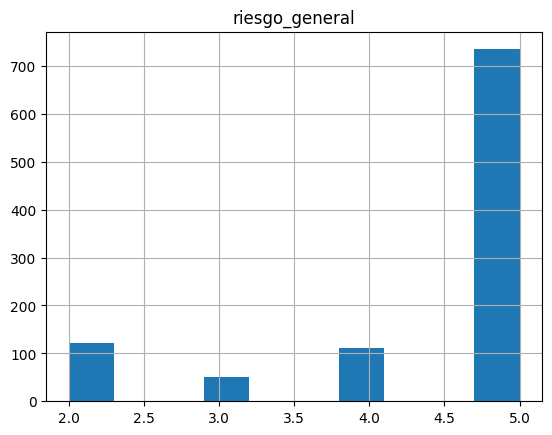

In [56]:
zonas_ageb_final.hist('riesgo_general')

In [57]:
# Copia de trabajo para limpieza (no modifica el dataset base)
zonas_ageb_clean = zonas_ageb_final.copy()

# Limpieza de datos
print("Estado inicial")
print(f"Filas: {zonas_ageb_clean.shape[0]}")
print(f"Columnas: {zonas_ageb_clean.shape[1]}")
print("Nulos totales:", int(zonas_ageb_clean.isna().sum().sum()))
print("Duplicados completos:", int(zonas_ageb_clean.duplicated().sum()))
if "CVEGEO" in zonas_ageb_clean.columns:
    print("Duplicados por CVEGEO:", int(zonas_ageb_clean.duplicated(subset="CVEGEO").sum()))

# 1) Normalización de registros de texto
columnas_texto = [
    c for c in zonas_ageb_clean.select_dtypes(include=["object"]).columns
    if c.lower() not in {"geometry", "geometria"}
]
for columna in columnas_texto:
    zonas_ageb_clean[columna] = zonas_ageb_clean[columna].astype(str).str.strip()
    if columna.upper() == "CVEGEO":
        zonas_ageb_clean[columna] = zonas_ageb_clean[columna].str.upper()

# 2) Eliminar duplicados
zonas_ageb_clean = zonas_ageb_clean.drop_duplicates()
if "CVEGEO" in zonas_ageb_clean.columns:
    zonas_ageb_clean = zonas_ageb_clean.drop_duplicates(subset="CVEGEO", keep="first")

# 3) Manejo de nulos
columnas_numericas = zonas_ageb_clean.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = [
    c for c in zonas_ageb_clean.columns
    if c not in columnas_numericas and c.lower() not in {"geometry", "geometria"}
]

for columna in columnas_numericas:
    mediana = zonas_ageb_clean[columna].median()
    zonas_ageb_clean[columna] = zonas_ageb_clean[columna].fillna(mediana)

for columna in columnas_categoricas:
    if zonas_ageb_clean[columna].isna().any():
        moda = zonas_ageb_clean[columna].mode(dropna=True)
        if len(moda) > 0:
            zonas_ageb_clean[columna] = zonas_ageb_clean[columna].fillna(moda.iloc[0])

# 4) Outliers: clipping por IQR solo si hay dispersión real
columnas_continuas = [
    c for c in ["area_total", "pct_afectacion_inundacion"]
    if c in zonas_ageb_clean.columns
]

for columna in columnas_continuas:
    q1 = zonas_ageb_clean[columna].quantile(0.25)
    q3 = zonas_ageb_clean[columna].quantile(0.75)
    iqr = q3 - q1
    if pd.notna(iqr) and iqr > 0:
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        zonas_ageb_clean[columna] = zonas_ageb_clean[columna].clip(lower=lim_inf, upper=lim_sup)

# 5) Normalización Min-Max en columnas continuas
for columna in columnas_continuas:
    minimo = zonas_ageb_clean[columna].min()
    maximo = zonas_ageb_clean[columna].max()
    nuevo_nombre = f"{columna}_norm"
    if pd.notna(minimo) and pd.notna(maximo) and maximo != minimo:
        zonas_ageb_clean[nuevo_nombre] = (zonas_ageb_clean[columna] - minimo) / (maximo - minimo)
    else:
        zonas_ageb_clean[nuevo_nombre] = 0.0

print("\nEstado final (zonas_ageb_clean)")
print(f"Filas: {zonas_ageb_clean.shape[0]}")
print(f"Columnas: {zonas_ageb_clean.shape[1]}")
print("Nulos totales:", int(zonas_ageb_clean.isna().sum().sum()))
print("Duplicados completos:", int(zonas_ageb_clean.duplicated().sum()))
if "CVEGEO" in zonas_ageb_clean.columns:
    print("Duplicados por CVEGEO:", int(zonas_ageb_clean.duplicated(subset="CVEGEO").sum()))

print("\nColumnas nuevas de normalización:")
print([c for c in zonas_ageb_clean.columns if c.endswith("_norm")])

Estado inicial
Filas: 1018
Columnas: 13
Nulos totales: 0
Duplicados completos: 0
Duplicados por CVEGEO: 0

Estado final (zonas_ageb_clean)
Filas: 1018
Columnas: 15
Nulos totales: 0
Duplicados completos: 0
Duplicados por CVEGEO: 0

Columnas nuevas de normalización:
['area_total_norm', 'pct_afectacion_inundacion_norm']


In [58]:
# Auditoría final de consistencia y extremos
columnas_pct = [c for c in ["pct_afectacion_sismo", "pct_afectacion_inundacion"] if c in zonas_ageb_clean.columns]
columnas_riesgo = ["riesgo_sismo", "riesgo_inundacion", "suma_riesgos", "riesgo_general"]

print("Valores únicos por columna:")
for columna in ["tipo_suelo", "area_total", "riesgo_sismo", "riesgo_inundacion", "suma_riesgos", "riesgo_general"]:
    print(f"- {columna}: {zonas_ageb_clean[columna].nunique()}")

print("\nFrecuencias de area_total:")
print(zonas_ageb_clean["area_total"].value_counts().head(10))

print("\nRevisión de porcentajes fuera de rango [0, 1]:")
for columna in columnas_pct:
    fuera_rango = zonas_ageb_clean[(zonas_ageb_clean[columna] < 0) | (zonas_ageb_clean[columna] > 1)]
    print(f"- {columna}: {len(fuera_rango)}")

riesgo_general_esperado = np.select(
    [
        (zonas_ageb_clean["suma_riesgos"] >= 1) & (zonas_ageb_clean["suma_riesgos"] <= 2),
        (zonas_ageb_clean["suma_riesgos"] >= 3) & (zonas_ageb_clean["suma_riesgos"] <= 4),
        (zonas_ageb_clean["suma_riesgos"] >= 5) & (zonas_ageb_clean["suma_riesgos"] <= 6),
        (zonas_ageb_clean["suma_riesgos"] >= 7) & (zonas_ageb_clean["suma_riesgos"] <= 8),
        (zonas_ageb_clean["suma_riesgos"] >= 9) & (zonas_ageb_clean["suma_riesgos"] <= 10),
    ],
    [1, 2, 3, 4, 5],
    default=0,
)

print("\nConsistencia de riesgo_general con suma_riesgos:", (riesgo_general_esperado == zonas_ageb_clean["riesgo_general"]).all())
print("\nDistribución de tipo_suelo:")
print(zonas_ageb_clean["tipo_suelo"].value_counts().sort_index())

# Mapear tipo_suelo a etiquetas legibles
mapping = {1: 'Roca', 2: 'Mixto', 3: 'Arenoso'}
zonas_ageb_clean['tipo_suelo_label'] = zonas_ageb_clean['tipo_suelo'].map(mapping)
print("\nEtiquetas `tipo_suelo` asignadas:")
print(zonas_ageb_clean['tipo_suelo_label'].value_counts())

# Mostrar algunas filas para inspección rápida
zonas_ageb_clean[['CVEGEO','tipo_suelo','tipo_suelo_label','area_total','riesgo_general']].head()


Valores únicos por columna:
- tipo_suelo: 3
- area_total: 3
- riesgo_sismo: 3
- riesgo_inundacion: 5
- suma_riesgos: 7
- riesgo_general: 4

Frecuencias de area_total:
area_total
6.681231e+08    717
1.393378e+09    161
2.979016e+08    140
Name: count, dtype: int64

Revisión de porcentajes fuera de rango [0, 1]:
- pct_afectacion_inundacion: 0

Consistencia de riesgo_general con suma_riesgos: True

Distribución de tipo_suelo:
tipo_suelo
1    161
2    140
3    717
Name: count, dtype: int64

Etiquetas `tipo_suelo` asignadas:
tipo_suelo_label
Arenoso    717
Roca       161
Mixto      140
Name: count, dtype: int64


,CVEGEO,tipo_suelo,tipo_suelo_label,area_total,riesgo_general
0,0900700011034,3,Arenoso,6.681231e+08,5
1,0900700013721,3,Arenoso,6.681231e+08,5
2,0900700013647,3,Arenoso,6.681231e+08,5
3,0900700015272,3,Arenoso,6.681231e+08,5
4,0900700010534,3,Arenoso,6.681231e+08,5


array([[<Axes: title={'center': 'riesgo_general'}>]], dtype=object)

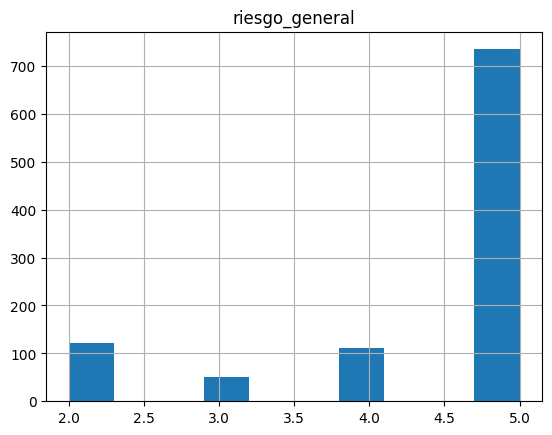

In [59]:
# Visualización final sobre la copia limpia
zonas_ageb_clean.hist('riesgo_general')


In [60]:
# suma_riesgos = riesgo_sismo + riesgo_inundacion (puede variar de 2 a 10)
# riesgo_general es una etiqueta numérica (1..5) que agrupa rangos de suma_riesgos:
#     1 -> suma 1-2 (Bajo)
#     2 -> suma 3-4 (Bajo-Medio)
#     3 -> suma 5-6 (Medio)
#     4 -> suma 7-8 (Medio-Alto)
#     5 -> suma 9-10 (Alto)

# Verificamos que la columna existente siga esta regla y mostramos discrepancias si existen
import numpy as np

condiciones = [
    (zonas_ageb_clean['suma_riesgos'] >= 1) & (zonas_ageb_clean['suma_riesgos'] <= 2),
    (zonas_ageb_clean['suma_riesgos'] >= 3) & (zonas_ageb_clean['suma_riesgos'] <= 4),
    (zonas_ageb_clean['suma_riesgos'] >= 5) & (zonas_ageb_clean['suma_riesgos'] <= 6),
    (zonas_ageb_clean['suma_riesgos'] >= 7) & (zonas_ageb_clean['suma_riesgos'] <= 8),
    (zonas_ageb_clean['suma_riesgos'] >= 9) & (zonas_ageb_clean['suma_riesgos'] <= 10),
]
valores = [1, 2, 3, 4, 5]
riesgo_esperado = np.select(condiciones, valores, default=0)

mismatches = zonas_ageb_clean[riesgo_esperado != zonas_ageb_clean['riesgo_general']]
print(f"Discrepancias encontradas: {len(mismatches)}")
if len(mismatches) > 0:
    display(mismatches[['CVEGEO','riesgo_sismo','riesgo_inundacion','suma_riesgos','riesgo_general']].head(20))
else:
    print("La columna `riesgo_general` es consistente con la regla definida.")

# Se puede recalcular riesgo_general desde cero y sobreescribir la columna en la copia:
# zonas_ageb_clean['riesgo_general_calc'] = riesgo_esperado
# zonas_ageb_clean[['riesgo_general', 'riesgo_general_calc']].head()


Discrepancias encontradas: 0
La columna `riesgo_general` es consistente con la regla definida.


In [61]:
# Exportar la copia limpia a GeoJSON en carpeta output
import os
out_dir = "output"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "zonas_ageb_clean.geojson")
zonas_ageb_clean.to_file(out_path, driver="GeoJSON")
print(f"Exportado zonas_ageb_clean a: {out_path}")


Exportado zonas_ageb_clean a: output\zonas_ageb_clean.geojson


## Resumen de limpieza y justificaciones

- Copia defensiva: se creó `zonas_ageb_clean = zonas_ageb_final.copy()` para proteger el dataset original antes de cualquier modificación.
- Diagnóstico inicial: comprobé filas, columnas, tipos, nulos y duplicados. Resultado: 1,018 filas, **13 columnas**, 0 nulos, 0 duplicados. Justificación: detectar problemas básicos antes de cualquier cambio.
- Auditoría final: revisé rangos, unicidades y consistencia entre columnas de riesgo. Verifiqué que los porcentajes están en [0,1] y que `riesgo_general` es consistente con `suma_riesgos`. Justificación: asegurar que las etiquetas derivadas sean coherentes.
- Etiquetado de `tipo_suelo`: añadí `tipo_suelo_label` con mapeo {1: 'Roca', 2: 'Mixto', 3: 'Arenoso'} para facilitar interpretación en análisis y visualizaciones.
- Exportación: guardé la copia limpia en `output/zonas_ageb_clean.geojson`. Justificación: mantener artefacto limpio para reproducibilidad y uso en etapas siguientes.

Indicaciones para revisar o reproducir:
- Para rehacer el diagnóstico, ejecutar la celda que contiene `zonas_ageb_clean` y las comprobaciones (diagnóstico inicial y auditoría fina).
- Para cambiar la regla de `riesgo_general`, revisar la celda que calcula `suma_riesgos` y la celda de verificación; si quieres, podemos recalcular y mantener ambas columnas (`riesgo_general` y `riesgo_general_calc`).

Notas:
- No se eliminaron filas ni valores sin justificación (no había nulos ni duplicados). Si deseas aplicar imputaciones o filtrados, documentaremos la regla y su efecto antes de aplicarla.
- Archivos de salida: `output/zonas_ageb_clean.geojson` (copia limpia). Originales conservados en `zonas_ageb_final` y en la carpeta `data/`.
